# 11 — Planning at Run Time

Model-predictive control by sampling, with the simulator as the model ·
SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/11-planning/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for the planner —
    MuJoCo renders the video through EGL on Colab, and that needs the
    GPU runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

The planner runs on the CPU and is slower than real time on Colab’s two
cores; the whole notebook takes a few minutes.

## Three ways to get a controller

| weeks | how | when the thinking happens |
|------------------------|------------------------|------------------------|
| 4–6 | **derive** it: LIPM, IK, PD, a filter | before the robot moves, by you |
| 7–10 | **learn** it: an MDP and PPO | before the robot moves, by an optimiser, for hours |
| **today** | **search** for it | *while* the robot moves, 25 times a second |

A planner keeps no controller at all. At every decision it asks *“what
happens next if I do this?”* — for sixty-four different *this* — and
does the best one for 40 ms. Then it asks again.

The question needs a model of the world that can be run forward. We have
had one since week 1.

**Layer 4, Control & Planning** — the half of it we have not used yet.

------------------------------------------------------------------------

## Colour code for the week

The same colours mean the same things in every equation and every
drawing:

| symbol | meaning | colour |
|------------------------|------------------------|------------------------|
| ${\color{#3b7dd8}{x_t}}$ | the robot’s **state** at step $t$: everything physics needs (`qpos`, `qvel`, …) | <span style="color:#3b7dd8">blue</span> |
| ${\color{#e8743b}{u_t}}$, ${\color{#e8743b}{U}}$ | a **control** at step $t$; the **plan** $U = (u_0, \dots, u_{H-1})$ | <span style="color:#e8743b">orange</span> |
| ${\color{#2a9d5c}{c}}$, ${\color{#2a9d5c}{J}}$ | the **cost** of one step; the total cost of one imagined future | <span style="color:#2a9d5c">green</span> |
| ${\color{#b07d12}{\varepsilon_k}}$, ${\color{#b07d12}{\sigma}}$ | a random **change** to the plan; its standard deviation (the sampling width) | <span style="color:#b07d12">gold</span> |
| ${\color{#8e44ad}{w_k}}$ | the **weight** given to future $k$ | <span style="color:#8e44ad">purple</span> |
| ${\color{#c0392b}{\lambda}}$ | the **temperature**: how strongly low cost wins the weight | <span style="color:#c0392b">red</span> |

$H$ is the **horizon** (how many plan steps ahead), $K$ the number of
sampled futures, $f$ the simulator:
${\color{#3b7dd8}{x_{t+1}}} = f({\color{#3b7dd8}{x_t}}, {\color{#e8743b}{u_t}})$.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180 @ git+https://github.com/gnoejh/soc4180.git"

import math, os, time
import numpy as np
import matplotlib.pyplot as plt
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
from mujoco import rollout
from soc4180 import planning

model = planning.planning_model()
q0, ctrl0 = planning.crouch(model)
torso = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso_link")
print(f"nsensor {model.nsensor} (two IMUs + {len(planning.SENSORS)} added)   nsensordata {model.nsensordata}")
print(f"cores here: {os.cpu_count()}")

nsensor 10 (two IMUs + 6 added)   nsensordata 30
cores here: 36

`planning_model()` is the G1 with six position sensors added by `MjSpec`
— both feet, both hands, the head and the centre of mass — so that every
future the planner imagines records where those things went.

------------------------------------------------------------------------

## Model-predictive control

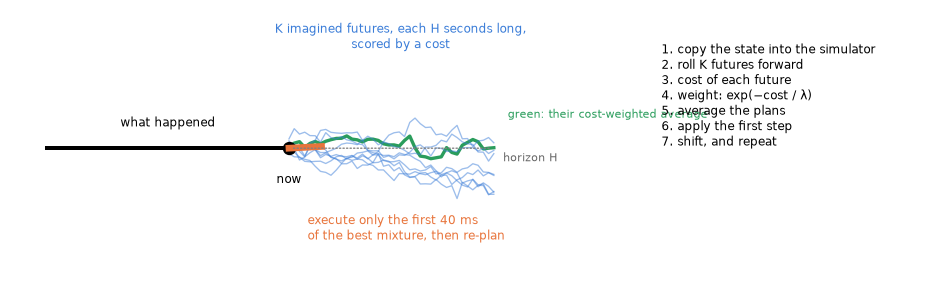

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.2)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 3.2)
rng = np.random.default_rng(1)
t = np.linspace(0, 2.2, 40)
for k in range(9):
    y = 1.6 + np.cumsum(rng.normal(0, 0.05, 40)) * (1 + 0.3 * k / 9)
    ax.plot(3 + t, y, color="#3b7dd8" if k else "#2a9d5c", lw=2.5 if k == 0 else 1, alpha=1 if k == 0 else 0.5)
ax.plot([0.4, 3], [1.6, 1.6], color="k", lw=3)
ax.plot(3, 1.6, "o", color="k", ms=9)
ax.plot([3, 3.35], [1.6, 1.62], color="#e8743b", lw=5)
ax.text(1.7, 1.85, "what happened", ha="center", fontsize=9)
ax.text(3.0, 1.2, "now", ha="center", fontsize=9)
ax.text(5.35, 1.95, "green: their cost-weighted average", fontsize=8, color="#2a9d5c")
ax.text(4.2, 2.75, "K imagined futures, each H seconds long,\nscored by a cost", ha="center", fontsize=9, color="#3b7dd8")
ax.text(3.2, 0.55, "execute only the first 40 ms\nof the best mixture, then re-plan", fontsize=9, color="#e8743b")
ax.annotate("", xy=(5.2, 1.6), xytext=(3.02, 1.6), arrowprops=dict(arrowstyle="-", ls=":", color="0.5"))
ax.text(5.3, 1.45, "horizon H", fontsize=8, color="0.4")
ax.text(7.0, 2.2, "1. copy the state into the simulator\n2. roll K futures forward\n"
                  "3. cost of each future\n4. weight: exp(−cost / λ)\n5. average the plans\n"
                  "6. apply the first step\n7. shift, and repeat", fontsize=9, va="center")
fig.tight_layout(); plt.show()

**Receding horizon**: the plan always reaches $H$ steps into the future,
and the future keeps moving. Nothing is learned. A plan that was right
40 ms ago is only a starting guess now. (The curves are a sketch of the
idea, not data.)

------------------------------------------------------------------------

## MPC, written as an optimisation problem

At every decision the planner tries to solve

$$\min_{{\color{#e8743b}{u_0}},\,\dots,\,{\color{#e8743b}{u_{H-1}}}} \;\;
{\color{#2a9d5c}{J}} = \sum_{t=0}^{H-1} {\color{#2a9d5c}{c}}({\color{#3b7dd8}{x_t}}, {\color{#e8743b}{u_t}})
\qquad\text{subject to}\qquad
{\color{#3b7dd8}{x_{t+1}}} = f({\color{#3b7dd8}{x_t}}, {\color{#e8743b}{u_t}}),\quad
{\color{#3b7dd8}{x_0}} = {\color{#3b7dd8}{x_{\text{now}}}}$$

- ${\color{#e8743b}{u_0, \dots, u_{H-1}}}$ — the **unknowns**: what to
  command at each of the next $H$ steps
- ${\color{#2a9d5c}{c}}({\color{#3b7dd8}{x_t}}, {\color{#e8743b}{u_t}})$
  — how bad step $t$ is (too low, tilted, rushing); **you write this**
- ${\color{#3b7dd8}{x_{t+1}}} = f(\cdot)$ — the future is not free: each
  state follows from the last by physics. Here $f$ **is** `mj_step` (20
  of them per 40 ms plan step; the code adds ${\color{#2a9d5c}{c}}$ up
  at every physics step)
- ${\color{#3b7dd8}{x_0}} = {\color{#3b7dd8}{x_{\text{now}}}}$ — every
  future starts from the robot as it is right now

It is week 3’s IK idea — *write down what you want as a number, then
search for the input that makes it small* — with two differences: the
unknown is a whole **sequence** of controls, and the number comes from
**running physics forward**, contacts and all.

How to solve it? Week 3 followed a gradient (the Jacobian). Here the
gradient would have to pass through 200 physics steps and every foot
contact that switches on or off along the way. **MPPI does not
differentiate $f$ at all**: it only runs it, many times, and compares
the answers.

------------------------------------------------------------------------

## Receding horizon, step by step

In [3]:
mppi_demo = planning.MPPI(model, ctrl0, planning.actuators_for(model))
print(f"H         = {mppi_demo.H} plan steps ('knots')")
print(f"one knot  = {mppi_demo.knot * 1000:.0f} ms = {mppi_demo.substeps} physics steps of {model.opt.timestep * 1000:.0f} ms, u held constant")
print(f"horizon   = {mppi_demo.H} x {mppi_demo.knot * 1000:.0f} ms = {mppi_demo.H * mppi_demo.knot:.1f} s = {mppi_demo.H * mppi_demo.substeps} physics steps")
print(f"u_t       = {len(mppi_demo.actuators)} numbers (leg servo targets, radians added to the crouch)")
print(f"unknowns  = {mppi_demo.H} x {len(mppi_demo.actuators)} = {mppi_demo.U.size}")
print(f"K         = {mppi_demo.K} futures per decision, sigma = {mppi_demo.sigma} rad, lambda = {mppi_demo.temperature}")

H         = 10 plan steps ('knots')
one knot  = 40 ms = 20 physics steps of 2 ms, u held constant
horizon   = 10 x 40 ms = 0.4 s = 200 physics steps
u_t       = 12 numbers (leg servo targets, radians added to the crouch)
unknowns  = 10 x 12 = 120
K         = 64 futures per decision, sigma = 0.15 rad, lambda = 0.05

**Step 1 — measure** ${\color{#3b7dd8}{x_{\text{now}}}}$
(`mj_getState`). **Step 2 — solve** the problem above, approximately,
starting from the old plan. **Step 3 — apply only**
${\color{#e8743b}{u_0}}$, for one knot (40 ms). **Step 4 — shift**:
${\color{#e8743b}{u_1, \dots, u_{H-1}}}$ become the first $H-1$ knots of
next time’s starting plan; a zero is appended at the end. Go to Step 1.

Each decision therefore costs $K \times$ (horizon in physics steps) = 64
× 200 = 12,800 physics steps, to choose 40 ms of action.

------------------------------------------------------------------------

## Receding horizon, drawn

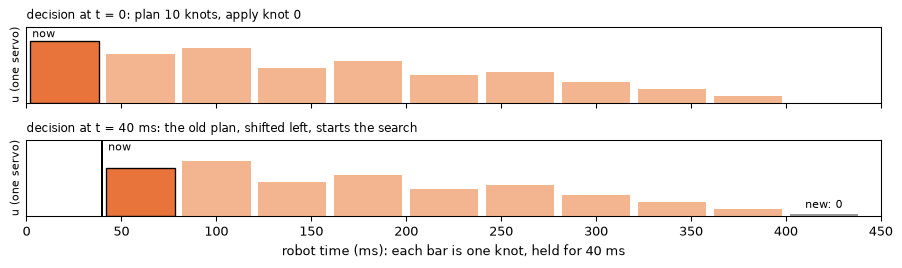

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(9.5, 2.9), sharex=True)
vals = np.array([0.9, 0.7, 0.8, 0.5, 0.6, 0.4, 0.45, 0.3, 0.2, 0.1])       # an illustrative plan, one servo
for row, (ax, title) in enumerate(zip(axs, ("decision at t = 0: plan 10 knots, apply knot 0",
                                            "decision at t = 40 ms: the old plan, shifted left, starts the search"))):
    v = vals if row == 0 else np.r_[vals[1:], 0.0]
    for i in range(10):
        col = "#e8743b" if i == 0 else "#f3b58f"
        ax.bar(i * 40 + 40 * row + 20, v[i], width=36, color=col, edgecolor="k" if i == 0 else "none")
    if row == 1:
        ax.bar(9 * 40 + 40 + 20, 0.03, width=36, color="0.6"); ax.text(9 * 40 + 60, 0.12, "new: 0", ha="center", fontsize=8)
    ax.axvline(40 * row, color="k", lw=1.5); ax.text(40 * row + 3, 0.95, "now", fontsize=8)
    ax.set_title(title, fontsize=9, loc="left"); ax.set_ylim(0, 1.1); ax.set_yticks([]); ax.set_ylabel("u (one servo)", fontsize=8)
axs[1].set_xlabel("robot time (ms): each bar is one knot, held for 40 ms"); axs[1].set_xlim(0, 450)
fig.tight_layout(); plt.show()

A diagram of the bookkeeping (bar heights illustrative). The horizon
slides 40 ms to the right every decision and always covers 0.4 s — it
*recedes* like a horizon as you walk toward it.

------------------------------------------------------------------------

## The simulator is the model

Every planner needs $x_{t+1} = f(x_t, u_t)$. Ours is **`mj_step`**.

In [5]:
data = mujoco.MjData(model)
data.qpos[:] = q0; data.qpos[2] = 0.74
mujoco.mj_forward(model, data)

spec = mujoco.mjtState.mjSTATE_FULLPHYSICS
state = np.empty(mujoco.mj_stateSize(model, spec))
mujoco.mj_getState(model, data, state, spec)          # the whole robot, as one vector
print(f"state vector: {state.size} numbers = time 1 + qpos {model.nq} + qvel {model.nv}"
      f" + {state.size - 1 - model.nq - model.nv} more (actuator states, warm start: none used here)")

K, steps = 64, 200                                     # 64 futures of 0.4 s
ctrl = np.tile(ctrl0, (K, steps, 1)) + np.random.default_rng(0).normal(0, 0.15, (K, steps, model.nu))
datas = [mujoco.MjData(model) for _ in range(min(16, os.cpu_count()))]
t0 = time.time()
states, sens = rollout.rollout(model, datas, np.tile(state, (K, 1)), ctrl, persistent_pool=True)
dt = time.time() - t0
print(f"rollout: {K} futures x {steps} steps = {K * steps:,} physics steps in {1000 * dt:.0f} ms "
      f"on {len(datas)} threads ({K * steps / dt:,.0f} steps/s)")
print(f"returned states {states.shape}, sensordata {sens.shape}")

state vector: 72 numbers = time 1 + qpos 36 + qvel 35 + 0 more (actuator states, warm start: none used here)
rollout: 64 futures x 200 steps = 12,800 physics steps in 69 ms on 16 threads (185,832 steps/s)
returned states (64, 200, 72), sensordata (64, 200, 30)

`mj_getState` flattens everything physics needs into one vector, so a
future can start from *exactly* now. `mujoco.rollout` then steps many
copies in C on a thread pool — one `MjData` per thread — and hands back
every state and every sensor reading of every future.

------------------------------------------------------------------------

## MPPI: which future?

**Model-predictive path integral** control (Williams et al., 2017) turns
$K$ scored futures into one plan:

$${\color{#8e44ad}{w_k}} = \frac{\exp(-{\color{#2a9d5c}{J_k}}/{\color{#c0392b}{\lambda}})}{\sum_j \exp(-{\color{#2a9d5c}{J_j}}/{\color{#c0392b}{\lambda}})}, \qquad
{\color{#e8743b}{U}} \leftarrow \sum_k {\color{#8e44ad}{w_k}}\,({\color{#e8743b}{U}} + {\color{#b07d12}{\varepsilon_k}})
= {\color{#e8743b}{U}} + \sum_k {\color{#8e44ad}{w_k}}\,{\color{#b07d12}{\varepsilon_k}}$$

- ${\color{#b07d12}{\varepsilon_k}}$ — random changes to the plan, drawn
  with standard deviation ${\color{#b07d12}{\sigma}}$ radians on each
  servo target at each knot
- ${\color{#2a9d5c}{J_k}}$ — the cost of future $k$, summed over its
  horizon
- ${\color{#8e44ad}{w_k}}$ — how much future $k$ counts; all positive,
  summing to 1
- ${\color{#c0392b}{\lambda}}$ — the **temperature**: small trusts only
  the best future, large averages everyone

The right-hand form reads: **move the plan by a weighted average of the
changes that were tried**, weighted towards the changes that went well.

It is week 8’s policy-gradient idea without a network: *make the plans
that went well more likely*, with the environment only scoring, never
differentiated. Here nothing is remembered between decisions except
${\color{#e8743b}{U}}$. The next three slides derive where the
exponential comes from.

------------------------------------------------------------------------

## Where the weights come from: Steps 1–2

**Step 1 — the obvious rule, and what is wrong with it.** Keep the best
future: ${\color{#8e44ad}{w_k}} = 1$ for the $k$ with smallest
${\color{#2a9d5c}{J_k}}$, 0 for the rest. With 64 random tries the
winner is partly luck, 63 of the 64 simulations are thrown away, and a
winner that is best by a hair and one that is best by a mile are treated
the same.

**Step 2 — ask for a compromise, as a number to minimise.** Look for
weights ${\color{#8e44ad}{w_k}} \ge 0$,
$\sum_k {\color{#8e44ad}{w_k}} = 1$, that make

$$F({\color{#8e44ad}{w}}) \;=\; \underbrace{\sum_k {\color{#8e44ad}{w_k}}\,{\color{#2a9d5c}{J_k}}}_{\text{average cost: favour good futures}}
\;+\; {\color{#c0392b}{\lambda}}\underbrace{\sum_k {\color{#8e44ad}{w_k}} \ln {\color{#8e44ad}{w_k}}}_{\text{penalty for putting all weight on one}}$$

as small as possible.

- The first term alone is minimised by Step 1’s rule (all weight on the
  best).
- The second term is $-$(entropy). It is **largest**, 0, when one
  ${\color{#8e44ad}{w_k}} = 1$, and **smallest**, $-\ln K$, when every
  ${\color{#8e44ad}{w_k}} = 1/K$. It pulls the weights towards spreading
  out.
- ${\color{#c0392b}{\lambda}}$ sets the exchange rate between the two:
  how many units of cost one unit of spreading is worth.

------------------------------------------------------------------------

## Where the weights come from: Steps 3–5

**Step 3 — set the derivative to zero.** Add
$\mu\,(\sum_k {\color{#8e44ad}{w_k}} - 1)$ to enforce the sum (a
Lagrange multiplier) and differentiate by one weight:

$$\frac{\partial}{\partial {\color{#8e44ad}{w_k}}}:\quad
{\color{#2a9d5c}{J_k}} + {\color{#c0392b}{\lambda}}\,(\ln {\color{#8e44ad}{w_k}} + 1) + \mu = 0
\;\;\Longrightarrow\;\;
\ln {\color{#8e44ad}{w_k}} = -\frac{{\color{#2a9d5c}{J_k}}}{{\color{#c0392b}{\lambda}}} - 1 - \frac{\mu}{{\color{#c0392b}{\lambda}}}
\;\;\Longrightarrow\;\;
{\color{#8e44ad}{w_k}} = C\,e^{-{\color{#2a9d5c}{J_k}}/{\color{#c0392b}{\lambda}}}$$

where $C = e^{-1-\mu/\lambda}$ is the same for every $k$.

**Step 4 — find $C$ from the sum.** $\sum_k {\color{#8e44ad}{w_k}} = 1$
gives
$C = 1/\sum_j e^{-{\color{#2a9d5c}{J_j}}/{\color{#c0392b}{\lambda}}}$,
which is the formula on the previous slide. It is called the
**softmin**: a soft version of “pick the minimum”.

**Step 5 — read it.** Compare two futures:

$$\frac{{\color{#8e44ad}{w_i}}}{{\color{#8e44ad}{w_j}}} = e^{-({\color{#2a9d5c}{J_i}} - {\color{#2a9d5c}{J_j}})/{\color{#c0392b}{\lambda}}}$$

**Every ${\color{#c0392b}{\lambda}}$ of extra cost divides the weight by
$e \approx 2.72$.** Only cost *differences* matter — which is why the
code may subtract ${\color{#2a9d5c}{J_{\min}}}$ from every cost first:
the weights do not change, and the largest exponential becomes $e^0 = 1$
instead of overflowing or underflowing.

------------------------------------------------------------------------

## The softmin, checked

In [6]:
rng_chk = np.random.default_rng(0)
Jk = rng_chk.uniform(0, 1, 8); lam_chk = 0.2

def F(w):                                            # average cost + lambda * sum w ln w
    return w @ Jk + lam_chk * np.sum(w * np.log(w))

w_soft = np.exp(-(Jk - Jk.min()) / lam_chk); w_soft /= w_soft.sum()
others = rng_chk.dirichlet(np.ones(8), 100_000)      # 100,000 random weightings that sum to 1
print(f"F(softmin weights)          = {F(w_soft):.5f}")
print(f"smallest F of 100,000 others = {min(F(w) for w in others):.5f}   (never lower)")
print(f"F(all weight on the best)    = {Jk.min():.5f}")
print(f"F(equal weights)             = {F(np.full(8, 1 / 8)):.5f}\n")

J_robot = np.array([90.0, 90.5, 93.0])               # the robot's best futures just after a 300 N shove cost ~90
with np.errstate(all="ignore"):
    raw = np.exp(-J_robot / 0.05); print("exp(-J/lambda) as written :", raw, "->", raw / raw.sum())
shifted = np.exp(-(J_robot - J_robot.min()) / 0.05)
print("after subtracting J_min  :", shifted / shifted.sum())

F(softmin weights)          = -0.15199
smallest F of 100,000 others = -0.14743   (never lower)
F(all weight on the best)    = 0.01653
F(equal weights)             = 0.08741

exp(-J/lambda) as written : [0. 0. 0.] -> [nan nan nan]
after subtracting J_min  : [9.99954602e-01 4.53978687e-05 8.75611324e-27]

- **Top block:** eight made-up costs,
  ${\color{#c0392b}{\lambda}} = 0.2$. The softmin weights give the
  smallest $F$; a hundred thousand random weightings never do better,
  and neither extreme (all on the best, all equal) comes close.
- **Bottom block:** written naively, $e^{-90/0.05} = e^{-1800}$ is
  smaller than the smallest number a computer can store (about
  $e^{-745}$): every weight becomes 0, and $0/0$ is `nan`. (Costs of
  about 90 are what the robot’s planner sees just after a 300 N shove —
  measured a few slides on.) Subtracting ${\color{#2a9d5c}{J_{\min}}}$
  first gives the weights the maths promises.
- **Last line**, read with Step 5: a future only 0.5 behind is
  $0.5/0.05 = 10$ temperatures behind, so it gets
  $e^{-10} \approx 4.5 \times 10^{-5}$ of the best one’s weight.

------------------------------------------------------------------------

## One MPPI update in one dimension

A **made-up** cost of a single number $u$, so that everything fits on
one drawing: a shallow valley on the left, a deeper one near $u = 1.2$.
The current plan is ${\color{#e8743b}{U}} = 0.4$; twelve changes are
drawn with ${\color{#b07d12}{\sigma}} = 0.5$ (the first is kept at 0, as
the planner does), and ${\color{#c0392b}{\lambda}} = 0.1$.

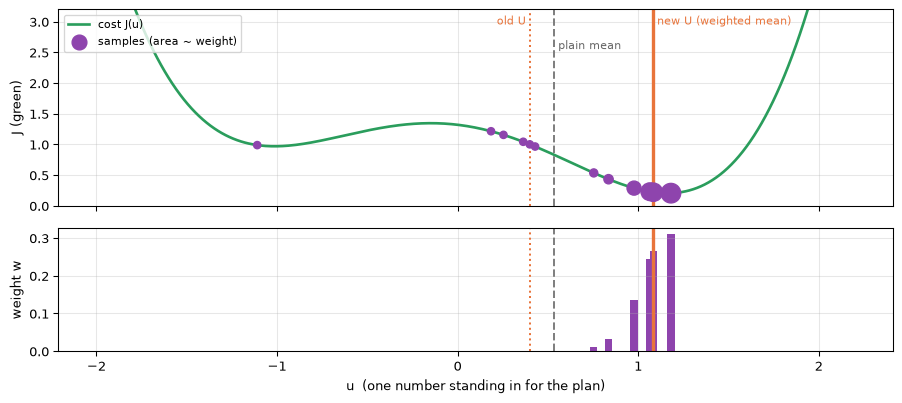

u : +1.18 +1.08 +1.06 +0.98 +0.84 +0.75 +0.43 -1.11 +0.40 +0.36 +0.25 +0.19
J :  0.21  0.22  0.23  0.29  0.43  0.54  0.97  0.99  1.00  1.04  1.16  1.21
w :  0.31  0.27  0.24  0.14  0.03  0.01  0.00  0.00  0.00  0.00  0.00  0.00
best sample +1.181   plain mean +0.535   weighted mean +1.083   (old U +0.400)

In [7]:
def J1(u):
    """A made-up 1-D cost: a shallow valley near u = -1, a deeper one near u = +1.2."""
    return 0.5 * (u ** 2 - 1.2) ** 2 - 0.35 * u + 0.6

def mppi_1d(U, sigma, lam, K, rng):
    eps = rng.normal(0, sigma, K); eps[0] = 0.0          # sample; keep the old plan as one candidate
    u = U + eps; J = J1(u)                               # simulate and score (here: just evaluate)
    w = np.exp(-(J - J.min()) / lam); w /= w.sum()       # softmin weights
    return u, J, w, w @ u                                # the new plan: the weighted mean

U_1d, sig_1d, lam_1d = 0.4, 0.5, 0.1
u_s, J_s, w_s, U_new = mppi_1d(U_1d, sig_1d, lam_1d, 12, np.random.default_rng(26))
uu = np.linspace(-2.0, 2.2, 400)
fig, (a0, a1) = plt.subplots(2, 1, figsize=(9.5, 4.3), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1]))
a0.plot(uu, J1(uu), color="#2a9d5c", lw=2, label="cost J(u)")
a0.scatter(u_s, J_s, s=30 + 600 * w_s, color="#8e44ad", zorder=3, label="samples (area ~ weight)")
a1.bar(u_s, w_s, width=0.04, color="#8e44ad")
for ax in (a0, a1):
    ax.axvline(U_1d, color="#e8743b", ls=":", lw=1.5)
    ax.axvline(u_s.mean(), color="0.5", ls="--", lw=1.5)
    ax.axvline(U_new, color="#e8743b", lw=2.5)
    ax.grid(alpha=0.3)
a0.text(U_1d, 3.1, "old U ", color="#e8743b", fontsize=8, va="top", ha="right")
a0.text(u_s.mean(), 2.7, " plain mean", color="0.4", fontsize=8, va="top")
a0.text(U_new, 3.1, " new U (weighted mean)", color="#e8743b", fontsize=8, va="top")
a0.set_ylim(0, 3.2); a0.set_ylabel("J (green)"); a0.legend(fontsize=8, loc="upper left")
a1.set_ylabel("weight w"); a1.set_xlabel("u  (one number standing in for the plan)")
fig.tight_layout(); plt.show()
order = np.argsort(J_s)                                  # the twelve samples, best first
print("u :", " ".join(f"{u_s[i]:+5.2f}" for i in order))
print("J :", " ".join(f"{J_s[i]:5.2f}" for i in order))
print("w :", " ".join(f"{w_s[i]:5.2f}" for i in order))
print(f"best sample {u_s[order[0]]:+.3f}   plain mean {u_s.mean():+.3f}   weighted mean {U_new:+.3f}   "
      f"(old U {U_1d:+.3f})")

------------------------------------------------------------------------

## Reading the 1-D update

- Each purple dot is one imagined future: a trial value of $u$ and its
  cost. **Low dots are big**: weight falls by $e$ for every
  ${\color{#c0392b}{\lambda}} = 0.1$ of extra cost.
- The **plain mean** (grey dashed) counts every sample equally, so the
  samples that did badly — including the one in the other valley — hold
  it close to where it started: 0.54 against the old 0.40.
- The **new ${\color{#e8743b}{U}}$** lands near the best samples but is
  not any one of them: it averages the few that did well.
- Nothing needed $dJ/du$. The planner only *evaluated* $J$ at twelve
  points — which is all a simulator can do for us.

Repeat this every decision, starting from the shifted old plan, and
${\color{#e8743b}{U}}$ walks downhill. On the robot, $u$ is 120 numbers
and each evaluation of ${\color{#2a9d5c}{J}}$ is 200 physics steps, but
the update is exactly this.

------------------------------------------------------------------------

## The temperature λ, drawn

Same twelve samples, same costs; only ${\color{#c0392b}{\lambda}}$
changes.

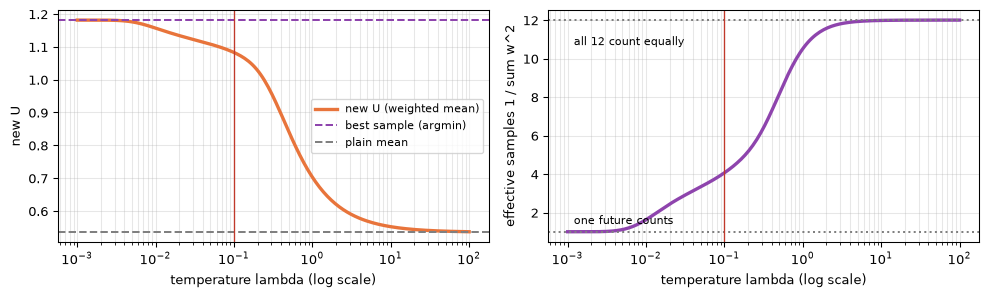

lambda  0.001: new U +1.181, effective samples  1.00 of 12
lambda    0.1: new U +1.083, effective samples  4.06 of 12
lambda    100: new U +0.537, effective samples 12.00 of 12

In [8]:
lams = np.logspace(-3, 2, 200)
means, ess = [], []
for lam_ in lams:
    w_ = np.exp(-(J_s - J_s.min()) / lam_); w_ /= w_.sum()
    means.append(w_ @ u_s); ess.append(1 / np.sum(w_ ** 2))
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10.4, 3.2))
a0.semilogx(lams, means, color="#e8743b", lw=2.5, label="new U (weighted mean)")
a0.axhline(u_s[np.argmin(J_s)], color="#8e44ad", ls="--", label="best sample (argmin)")
a0.axhline(u_s.mean(), color="0.5", ls="--", label="plain mean")
a0.set_xlabel("temperature lambda (log scale)"); a0.set_ylabel("new U"); a0.legend(fontsize=8)
a1.semilogx(lams, ess, color="#8e44ad", lw=2.5)
a1.axhline(1, color="0.5", ls=":"); a1.axhline(len(u_s), color="0.5", ls=":")
a1.text(1.2e-3, 1.4, "one future counts", fontsize=8); a1.text(1.2e-3, len(u_s) - 1.3, "all 12 count equally", fontsize=8)
a1.set_xlabel("temperature lambda (log scale)"); a1.set_ylabel("effective samples 1 / sum w^2")
for ax in (a0, a1):
    ax.axvline(lam_1d, color="#c0392b", lw=1); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); plt.show()
for lam_ in (0.001, 0.1, 100):
    w_ = np.exp(-(J_s - J_s.min()) / lam_); w_ /= w_.sum()
    print(f"lambda {lam_:>6}: new U {w_ @ u_s:+.3f}, effective samples {1 / np.sum(w_ ** 2):5.2f} of {len(u_s)}")

- ${\color{#c0392b}{\lambda}} \to 0$: $e^{-\Delta J/\lambda}$ crushes
  everything but the best → **argmin**, Step 1’s rule.
- ${\color{#c0392b}{\lambda}} \to \infty$: $e^{-\Delta J/\lambda} \to 1$
  for all → equal weights, the **plain mean**: the costs are ignored.
- The **effective number of samples**
  $1/\sum_k {\color{#8e44ad}{w_k}}^2$ counts how many futures really
  vote: 1 if one weight is 1, $K$ if all are $1/K$. The red line is the
  ${\color{#c0392b}{\lambda}}$ used on the previous slide.

------------------------------------------------------------------------

## The sampling width σ, drawn

Start in the **shallow** valley, ${\color{#e8743b}{U}} = -1$, and repeat
the update 30 times (16 samples, ${\color{#c0392b}{\lambda}} = 0.1$): 20
runs per width, the first five drawn.

sigma 0.1:  0/20 escape;  final U spread (std) 0.034
sigma 0.8: 20/20 escape;  final U spread (std) 0.038
sigma 3.0: 20/20 escape;  final U spread (std) 0.059

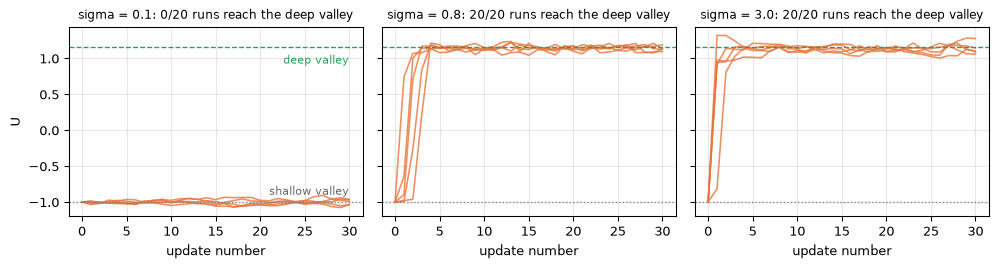

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(10.5, 2.9), sharey=True)
for ax, sig in zip(axs, (0.1, 0.8, 3.0)):
    finals = []
    for seed in range(20):
        r_ = np.random.default_rng(seed); U_ = -1.0; path = [U_]
        for _ in range(30):
            U_ = mppi_1d(U_, sig, 0.1, 16, r_)[3]; path.append(U_)
        finals.append(U_)
        if seed < 5:
            ax.plot(path, color="#e8743b", lw=1.2, alpha=0.8)
    finals = np.array(finals)
    ax.axhline(uu[np.argmin(J1(uu))], color="#2a9d5c", ls="--", lw=1)
    ax.axhline(-1.0, color="0.5", ls=":", lw=1)
    ax.set_title(f"sigma = {sig}: {np.sum(finals > 0)}/20 runs reach the deep valley", fontsize=9)
    ax.set_xlabel("update number"); ax.grid(alpha=0.3)
    print(f"sigma {sig}: {np.sum(finals > 0):2d}/20 escape;  final U spread (std) {finals.std():.3f}")
axs[0].set_ylabel("U"); axs[0].text(30, -0.9, "shallow valley", ha="right", fontsize=8, color="0.4")
axs[0].text(30, 1.05, "deep valley", ha="right", va="top", fontsize=8, color="#2a9d5c")
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Reading σ

- **Too narrow**: every sample lands in the same valley, so every sample
  says “stay”. The planner cannot prefer a future it never imagined — it
  is stuck in a **local minimum**, the same kind of trap as the SQUAT
  slide later today.
- **Wide enough**: a few samples land in the deep valley, win the
  weight, and pull the plan across.
- **Too wide**: most samples land far up the walls with huge cost and
  almost no weight; the few that count are scattered, so the plan
  settles less precisely. Over the 20 runs the final
  ${\color{#e8743b}{U}}$ scatters by a standard deviation of 0.059 at
  ${\color{#b07d12}{\sigma}} = 3$ against 0.038 at 0.8. Wider costs
  precision.

${\color{#b07d12}{\sigma}}$ and $K$ trade against each other: a rare
good future is found by drawing *more* samples, or by drawing them
*further out*. That is the robot table later today — 16 samples at
${\color{#b07d12}{\sigma}} = 0.15$ miss stepping under 300 N; 16 samples
at ${\color{#b07d12}{\sigma}} = 0.25$ find it.

------------------------------------------------------------------------

## The whole planner

`soc4180.planning.MPPI.plan`, without the bookkeeping:

``` python
def plan(self, data):
    mujoco.mj_getState(self.model, data, self._state, self._spec)          # 1. where we are
    eps = self.rng.normal(0.0, self.sigma, (self.K, self.H, len(self.actuators)))
    eps[0] = 0.0                                                            # keep the old plan as a candidate
    U = self.U[None] + eps                                                  # 2. K perturbed plans
    ctrl = np.tile(self.nominal_ctrl, (self.K, self.H, 1))
    ctrl[:, :, self.actuators] += U
    ctrl = np.repeat(ctrl, self.substeps, axis=1)                           #    each knot held 40 ms
    states, sens = rollout.rollout(self.model, self._datas,                 # 3. K futures, in parallel
                                   np.tile(self._state, (self.K, 1)), ctrl, persistent_pool=True)
    costs = self.cost(Rollouts(self.model, states, sens, self._adr))        # 4. score
    w = np.exp(-(costs - costs.min()) / self.temperature)                   # 5. weight
    w /= w.sum()
    self.U = np.einsum("k,khn->hn", w, U)                                   # 6. average
    u0 = self.U[0].copy()
    self.U = np.roll(self.U, -1, axis=0); self.U[-1] = 0.0                  # 7. shift
    return self.nominal_ctrl + (u0 on the planned servos)
```

The plan is 10 **knots** of 40 ms over the twelve leg servos’ targets —
120 numbers — added to the week-4 crouch. `costs.min()` is subtracted
before the exponential only so that it never overflows.

------------------------------------------------------------------------

## The cost *is* the specification

``` python
def standing_cost(r):
    mid = 0.5 * (r.foot("left") + r.foot("right"))
    c = (10.0 * (r.pelvis_height - 0.72) ** 2                               # stay tall
         + 5.0 * (1.0 - r.upright)                                          # stay upright
         + 20.0 * np.sum((r.com[..., :2] - mid[..., :2]) ** 2, axis=-1)     # mass over the feet
         + 0.01 * np.sum(r.qvel[..., :6] ** 2, axis=-1)                     # do not rush about
         + 100.0 * (r.pelvis_height < 0.5))                                 # do not be on the floor
    return c.sum(axis=1)                                                    # one number per future
```

Every accessor is $K \times T$: one row per future, one column per
physics step. Four lines of numpy say what *balance* means. **Nothing
says how**: not “use the ankles”, not “step”, not “bend at the hips”.

It is week 9’s reward, turned upside down and evaluated on the future
instead of the past.

------------------------------------------------------------------------

## On the robot: how many futures vote?

Run the real planner for 1.5 s from the crouch, with a 300 N sideways
shove from 1.0 to 1.2 s, and keep the 64 costs of every decision:

In [10]:
d_w = mujoco.MjData(model); d_w.qpos[:] = q0; d_w.qpos[2] = 0.74; mujoco.mj_forward(model, d_w)
mppi_w = planning.MPPI(model, ctrl0, planning.actuators_for(model))
cost_log = []
while d_w.time < 1.5:
    c_ = mppi_w.plan(d_w); cost_log.append((d_w.time, mppi_w.last_costs.copy()))
    for _ in range(mppi_w.substeps):
        d_w.xfrc_applied[torso, 1] = 300 if 1.0 <= d_w.time < 1.2 else 0.0
        d_w.ctrl[:] = c_; mujoco.mj_step(model, d_w)

def ess_of(J, lam):
    w = np.exp(-(J - J.min()) / lam); w /= w.sum()
    return 1 / np.sum(w ** 2)

for label, sel in (("before the shove (t < 1.0 s)", [c for t, c in cost_log if t < 1.0]),
                   ("during and after (t >= 1.0 s)", [c for t, c in cost_log if t >= 1.0])):
    spread = np.median([c.max() - c.min() for c in sel]); lowest = np.median([c.min() for c in sel])
    gap = np.median([np.sort(c)[1] - np.sort(c)[0] for c in sel])
    row = "  ".join(f"lam {l:<5}: {np.median([ess_of(c, l) for c in sel]):5.1f}" for l in (0.005, 0.05, 0.5, 5.0))
    print(f"{label}: best J ~ {lowest:6.1f}, runner-up behind by ~ {gap:5.2f}, worst behind by ~ {spread:6.1f}")
    print(f"    median effective samples of 64 ->  {row}")

before the shove (t < 1.0 s): best J ~    2.5, runner-up behind by ~  8.87, worst behind by ~  168.7
    median effective samples of 64 ->  lam 0.005:   1.0  lam 0.05 :   1.0  lam 0.5  :   1.0  lam 5.0  :   4.7
during and after (t >= 1.0 s): best J ~   90.1, runner-up behind by ~  3.76, worst behind by ~  681.2
    median effective samples of 64 ->  lam 0.005:   1.0  lam 0.05 :   1.0  lam 0.5  :   1.0  lam 5.0  :   3.4

Read it with Step 5: what matters is the **spread** of costs measured in
units of ${\color{#c0392b}{\lambda}}$. The worst future costs hundreds
more than the best, and even the runner-up is typically 4 to 9 behind —
at the planner’s default ${\color{#c0392b}{\lambda}} = 0.05$ that is 75
to 180 temperatures, a weight of $e^{-75}$ or less. So the **effective
number of samples is 1**. On this robot, with this cost, MPPI is in
practice Step 1’s rule: *keep the best of 64*. The averaging only begins
around ${\color{#c0392b}{\lambda}} = 5$.

That is not a bug — it stands at 300 N, as the next slides show — but it
means the 1-D picture’s gentle averaging is not what happens here.
Exercise 1 asks what changes when you raise
${\color{#c0392b}{\lambda}}$.

------------------------------------------------------------------------

## Shove it

In [11]:
def run(push, controller="mppi", seconds=4.0, samples=64, sigma=0.15, record=False):
    d = mujoco.MjData(model); d.qpos[:] = q0; d.qpos[2] = 0.74; mujoco.mj_forward(model, d)
    mppi = planning.MPPI(model, ctrl0, planning.actuators_for(model), samples=samples, sigma=sigma)
    feet = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, f"{s}_foot") for s in ("left", "right")]
    start = [d.site_xpos[f][:2].copy() for f in feet]
    ctrl, frames, trace, zmin, t_plan, n = ctrl0.copy(), [], [], 9.0, 0.0, 0
    while d.time < seconds:
        if controller == "mppi":
            t0 = time.time(); ctrl = mppi.plan(d); t_plan += time.time() - t0; n += 1
        for _ in range(mppi.substeps):
            d.xfrc_applied[torso, 1] = push if 1.0 <= d.time < 1.2 else 0.0
            d.ctrl[:] = ctrl; mujoco.mj_step(model, d)
            if record and round(d.time / model.opt.timestep) % 17 == 0:
                frames.append(d.qpos.copy())
        zmin = min(zmin, d.qpos[2])
        trace.append((d.time, d.qpos[1], *[d.site_xpos[f][1] for f in feet], d.qpos[2]))
    x, y = d.qpos[4], d.qpos[5]
    tilt = math.degrees(math.acos(min(1.0, 1 - 2 * (x * x + y * y))))
    fell = zmin < 0.5 or tilt > 15
    return dict(fell=fell, zmin=zmin, tilt=tilt, ms=1000 * t_plan / max(n, 1), frames=frames, trace=np.array(trace),
                moved=sum(np.linalg.norm(d.site_xpos[f][:2] - s) for f, s in zip(feet, start)))

results = {}
for label, push, ctl in (("hold the crouch, 65 N", 65, "hold"), ("hold the crouch, 70 N", 70, "hold"),
                         ("MPPI, 150 N", 150, "mppi"), ("MPPI, 300 N", 300, "mppi")):
    results[label] = r = run(push, ctl, record=(label == "MPPI, 300 N"))
    print(f"{label:24s} {'FELL ' if r['fell'] else 'stood'}  lowest pelvis {r['zmin']:.2f} m   "
          f"feet travelled {r['moved']:.2f} m" + (f"   {r['ms']:.0f} ms per decision" if ctl == "mppi" else ""))

hold the crouch, 65 N    stood  lowest pelvis 0.75 m   feet travelled 0.06 m
hold the crouch, 70 N    FELL   lowest pelvis 0.04 m   feet travelled 0.25 m
MPPI, 150 N              stood  lowest pelvis 0.73 m   feet travelled 3.10 m   82 ms per decision
MPPI, 300 N              stood  lowest pelvis 0.70 m   feet travelled 6.96 m   83 ms per decision

Week 7 found the crouch falls at 70 N and the ankle strategy at 80 N.
The planner, with a four-line cost, stands at **300**.

How to read a line: `lowest pelvis` is the lowest the pelvis got in 4 s
(it starts at 0.74 m; below 0.5 m counts as a fall, as does ending
tilted more than 15°). `feet travelled` adds the two feet’s distances
from where they started — a few centimetres means the feet stayed put;
metres means the robot walked.

------------------------------------------------------------------------

## How: it steps

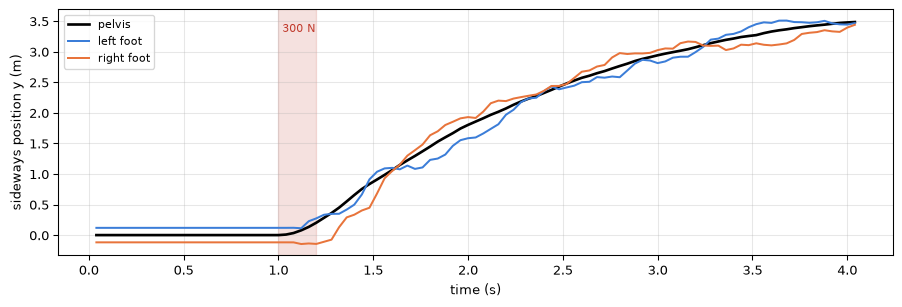

In [12]:
tr = results["MPPI, 300 N"]["trace"]
fig, ax = plt.subplots(figsize=(9.5, 3.3))
ax.plot(tr[:, 0], tr[:, 1], color="k", lw=2, label="pelvis")
ax.plot(tr[:, 0], tr[:, 2], color="#3b7dd8", lw=1.5, label="left foot")
ax.plot(tr[:, 0], tr[:, 3], color="#e8743b", lw=1.5, label="right foot")
ax.axvspan(1.0, 1.2, color="#c0392b", alpha=0.15); ax.text(1.02, ax.get_ylim()[1] * 0.9, "300 N", fontsize=8, color="#c0392b")
ax.set_xlabel("time (s)"); ax.set_ylabel("sideways position y (m)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

After the shove the feet chase the pelvis: one lifts and lands further
along, then the other, sometimes crossing. **The planner discovered
stepping** — the one recovery week 7 said no stance could do — because
among 64 random futures some happened to put a foot out, and those were
the ones that did not end on the floor.

And it never stops: the pelvis is still moving sideways at 4 s, metres
from where it started. The cost asks for balance, not for *staying where
you are*.

------------------------------------------------------------------------

## Watch it

In [13]:
frames = results["MPPI, 300 N"]["frames"]
video = soc4180.render_poses(model, frames, width=480, height=360)
soc4180.show_video(video, fps=30)

A 0.2 s shove of 300 N is an impulse of 60 N·s into a 33 kg robot — 1.8
m/s sideways. The planner cannot stop that in one step, and nothing in
its cost rewards stopping, so it walks sideways instead. Add a term for
“stay near the start” and it has to decide how much balance that is
worth.

------------------------------------------------------------------------

## How much thinking is enough?

Measured with `plan.py --samples K --push F` (4 s, seed 0), on this
laptop:

| samples $K$         | 150 N  | 300 N      | physics steps per decision |
|---------------------|--------|------------|----------------------------|
| 2                   | falls  | falls      | 400                        |
| 4                   | stands | falls      | 800                        |
| 16                  | stands | falls      | 3,200                      |
| 16, $\sigma$ = 0.25 | stands | **stands** | 3,200                      |
| 64                  | stands | stands     | 12,800                     |

Two lessons in one table. **More samples find rarer good futures** —
stepping under 300 N is rare enough that 16 random tries at
$\sigma = 0.15$ miss it. And **exploration width trades against sample
count**: sixteen futures that each wander further ($\sigma = 0.25$) find
it again. In the lab, problem 4 is exactly this.

------------------------------------------------------------------------

## The price of thinking

In [14]:
ms = results["MPPI, 300 N"]["ms"]
print(f"one decision: {ms:.0f} ms of planning for 40 ms of robot time -> {40 / ms:.2f}x real time on {len(datas)} threads")

one decision: 83 ms of planning for 40 ms of robot time -> 0.48x real time on 16 threads

|                         | per decision | what it costs              |
|-------------------------|--------------|----------------------------|
| hold the crouch         | 0            | nothing, and falls at 70 N |
| week 7’s ankle strategy | ~1 µs        | two multiplications        |
| a PPO policy (week 12)  | ~0.1 ms      | one small network          |
| **MPPI, 64 × 0.4 s**    | **~100 ms**  | **12,800 physics steps**   |

Read the printed ratio: below 1 means the planner is *slower* than the
robot it drives — on the 36-core machine these slides were written on,
about half of real time when the machine is idle (74 ms a decision) and
a third when it is busy; a laptop with fewer cores, less. Real systems
that plan this way (DeepMind’s MuJoCo MPC, Boston Dynamics’ Atlas) run a
simplified model, fewer samples, or a GPU. **Weeks 12 and 13 are both
answers to this slide**: learn a policy that is fast to run, or copy a
slow planner into one.

------------------------------------------------------------------------

## A cost that says too little

What if the cost only says what we *really* care about — do not fall?

| STAND cost | no push | 150 N | 300 N |
|------------------|------------------|------------------|------------------|
| height 10, upright 5, over_feet 20, still 0.01, fall 100 | stands | stands | stands |
| … with any **one** of height, upright, over_feet at 0 | stands | stands | stands |
| **only** `fall`: 100 | **falls** | falls | falls |
| only `still`: 0.01 | stands | falls | falls |
| everything 0 | falls in 1.4 s | falls | falls |

Measured with `lab_plan.py`. The sparse cost falls **with no push at
all**: the planner looks 0.4 s ahead, and a fall that starts now is not
below 0.5 m yet — every future looks equally good until it is too late.
*Dense* terms (height, uprightness) say “worse” early enough to act on.
That is week 9’s lesson about sparse rewards, from the other side.

------------------------------------------------------------------------

## A cost that is stuck

The squat: pelvis to 0.55 m, then back up.

| SQUAT cost                        | lowest pelvis | result            |
|-----------------------------------|---------------|-------------------|
| height **20**, balance terms on   | 0.745 m       | never moves       |
| height **100**, balance terms on  | 0.503 m       | squats, stands up |
| height 100, balance terms **off** | —             | falls             |

With weight 20, every sampled future that starts *down* also tilts a
little, and the tilt costs more than the first centimetres of squat
earn. The unperturbed plan — stand still — wins every decision, forever.
A **local minimum**: search only looks nearby, and nearby is uphill.

Raising the weight makes going down pay immediately. Removing the
balance terms makes it pay too much.

------------------------------------------------------------------------

## A cost that is obeyed

Problem 5 asks for the left foot 5 cm off the floor for two seconds,
with the centre of mass over the right foot. The planner does it — by
**hopping**, two metres across the floor on the right foot.

Nothing in the cost said *don’t hop*. Adding a term that keeps the right
foot on the floor (`plant_right`) stops the hopping at exactly one
weight we found, and falls or hops again at half and double — too
fragile to grade.

> The planner does what the cost says, not what you meant.

This is the same sentence as week 9’s reward hacking, and it will be
true of every optimiser you ever use.

------------------------------------------------------------------------

## A model that is wrong

The planner has always had a perfect model: the same `MjModel` as the
world. `plan.py --model-mass` makes the *planner’s* torso heavier or
lighter; the world does not change.

| planner’s torso vs the world’s 7.82 kg | 150 N  | 300 N  |
|----------------------------------------|--------|--------|
| exact                                  | stands | stands |
| −10 kg                                 | falls  | falls  |
| +10 kg                                 | stands | falls  |
| +20 kg                                 | stands | falls  |
| +40 kg                                 | falls  | falls  |

Each future is only as good as the model that imagines it. A real robot
has no exact model — so a real planner uses one it can **measure**
(system identification), one that is deliberately **simple**, or it is
**learned**. Weeks 12 and 13 come at the same gap from the policy side.

------------------------------------------------------------------------

## Where you will see this again

- **MuJoCo MPC** (DeepMind, 2022): predictive sampling, iLQG and
  gradient planners running live in MuJoCo’s viewer — the same idea as
  today, in C++.
- **Convex MPC on legged robots** (MIT Cheetah 3, 2018): a simplified
  model (a single rigid body) solved exactly, 30 times a second.
- **TD-MPC2** (Hansen et al., 2024): MPPI in the latent space of a
  **learned** world model, with a learned value function beyond the
  horizon.
- **Every chess and Go program**: search at run time, guided by learned
  evaluations. AlphaZero is a planner with a network inside.

The recurring shape: search where it is cheap, learn where it is not.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/11-planning/lab_plan.py        # edit costs.py; no torch needed
```

A game, like week 3’s. **You edit only `costs.py`**: the weights of each
problem’s cost and the planner’s settings. `1`–`6` play a problem live
(slow motion — the planner is thinking), `G` grades all six, the scorer
code on the final screen proves the referee is unchanged. `costs.py`
ships with its key numbers as `...` and scores 0 / 6.

| \# | Problem | What it teaches |
|------------------------|------------------------|------------------------|
| 1–3 | stand; 150 N; 300 N | a dense cost; stepping emerges |
| 4 | 300 N with ≤ 16 samples | exploration width against sample count |
| 5 | CRANE: one foot up for 2 s | the planner obeys the cost — watch *how* |
| 6 | SQUAT and stand up | a local minimum, and the weight that escapes it |

------------------------------------------------------------------------

## Lab class: `plan.py`

``` bash
uv run weeks/11-planning/plan.py --push 300
uv run weeks/11-planning/plan.py --controller hold --push 70
uv run weeks/11-planning/plan.py --samples 16 --sigma 0.25 --push 300
uv run weeks/11-planning/plan.py --model-mass -10 --push 150
uv run weeks/11-planning/plan.py --task crane --seconds 6
```

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | the world, and the planner’s own copy | `MjSpec.add_sensor`, `compile`, `body_mass` |
| 2 | the planner | `planning.MPPI`, `actuators_for` |
| 3 | plan, apply one knot, repeat | `mj_getState`, `rollout.rollout`, `mj_step`, `xfrc_applied` |
| 4 | the outcome and the cost of thinking |  |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **Temperature.** Sweep $\lambda$ from 0.005 to 5 at 300 N. What
    happens at each end, and why does the average of *all* futures fail?
2.  **Horizon.** At what horizon does the 300 N recovery stop working?
    Relate it to how long one step takes.
3.  **A lighter planner.** Plan with `model.opt.timestep = 0.004` in the
    planner’s model only (half the physics steps). Is it still good
    enough?
4.  **More servos.** Let the planner move the waist too
    (`--chains left_leg right_leg waist`). Does it use the
    hips-and-torso strategy?
5.  **Push from the front.** Change `xfrc_applied[torso, 1]` to index 0.
    Which way is harder, and what does the planner do with its arms
    locked?
6.  **Your own task.** Write a cost that keeps the left hand at a point
    40 cm in front of the chest while standing. Which terms did you
    need?

------------------------------------------------------------------------

## Next week

**12 — Robustness.** The planner cost 100 ms a decision and needed a
perfect model. A PPO policy costs 0.1 ms — and knows only the world it
trained in. We train one to take a shove, then change the world under
it: ice, a heavier torso, weaker motors. **Domain randomisation** is the
fix, and we measure what it buys.